In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Import Libraries

In [ ]:
!pip install googletrans==4.0.0-rc1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from googletrans import Translator

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report

In [ ]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

Data Loading

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/AI-ML-DL/reviews_dataset.csv",encoding="ISO-8859-1")
df

,review_body,stars
0,"Normal, ni bien ni mal.",3
1,"Muy mala calidad, no lo recomiendo.",1
2,No funciona correctamente.,1
3,Estoy muy satisfecho con la compra.,5
4,Nada fuera de lo normal.,3
...,...,...
995,Cumple con lo básico.,3
996,Está bien por el precio.,3
997,Excelente calidad y muy buen precio.,5
998,Nada fuera de lo normal.,3


EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_body  1000 non-null   object
 1   stars        1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


In [ ]:
df.describe()

,stars
count,1000.000000
mean,3.038000
std,1.611569
min,1.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,5.000000


In [ ]:
df.shape

(1000, 2)

In [ ]:
df.columns

Index(['review_body', 'stars'], dtype='object')

In [ ]:
df.isnull().sum()

,0
review_body,0
stars,0


In [ ]:
nltk.download("wordnet",download_dir="/content/drive/MyDrive/nltk_data/")
nltk.download("punkt_tab")
nltk.download("punkt")

[nltk_data] Downloading package wordnet to
[nltk_data]     /content/drive/MyDrive/nltk_data/...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
#creating lemmatizer & stop_words object
lemmatizer=WordNetLemmatizer()
stop_words=set(stopwords.words("spanish"))

In [ ]:
# creating text preprocessing function & appyling to df
def preprocess_text(text):
  text=text.lower()
  text = re.sub(r'<.*?>%&', '', text)
  text = re.sub(r'http\S+|www\S+', '', text)
  text = re.sub(r'[^a-záéíóúñ\s]', '', text)
  tokens = word_tokenize(text)
  tokens = [word for word in tokens if word not in stop_words]
  tokens = [lemmatizer.lemmatize(word) for word in tokens]
  return " ".join(tokens)

df['cleaned_review']=df['review_body'].apply(preprocess_text)
df

,review_body,stars,cleaned_review
0,"Normal, ni bien ni mal.",3,normal bien mal
1,"Muy mala calidad, no lo recomiendo.",1,mala calidad recomiendo
2,No funciona correctamente.,1,funciona correctamente
3,Estoy muy satisfecho con la compra.,5,satisfecho compra
4,Nada fuera de lo normal.,3,normal
...,...,...,...
995,Cumple con lo básico.,3,cumple básico
996,Está bien por el precio.,3,bien precio
997,Excelente calidad y muy buen precio.,5,excelente calidad buen precio
998,Nada fuera de lo normal.,3,normal


In [ ]:
#creating translator object
translator=Translator()

# creating translation function
def translate_text(text):
  try:
    translation=translator.translate(text,src="es",dest="en")
    return translation.text

  except:
    return text

df['review_en']=df['review_body'].apply(translate_text)

In [ ]:
df['review_en']

,review_en
0,"Normal, neither good nor bad."
1,"Very poor quality, I do not recommend it."
2,It doesn't work properly.
3,I am very satisfied with the purchase.
4,Nothing out of the ordinary.
...,...
995,Comply with the basics.
996,It's good for the price.
997,Excellent quality and very good price.
998,Nothing out of the ordinary.


In [ ]:
df['stars'].unique()

array([3, 1, 5])

In [ ]:
df['stars'].value_counts()

,count
stars,
3,351
5,334
1,315


/tmp/ipython-input-4149206512.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='stars',palette='husl')


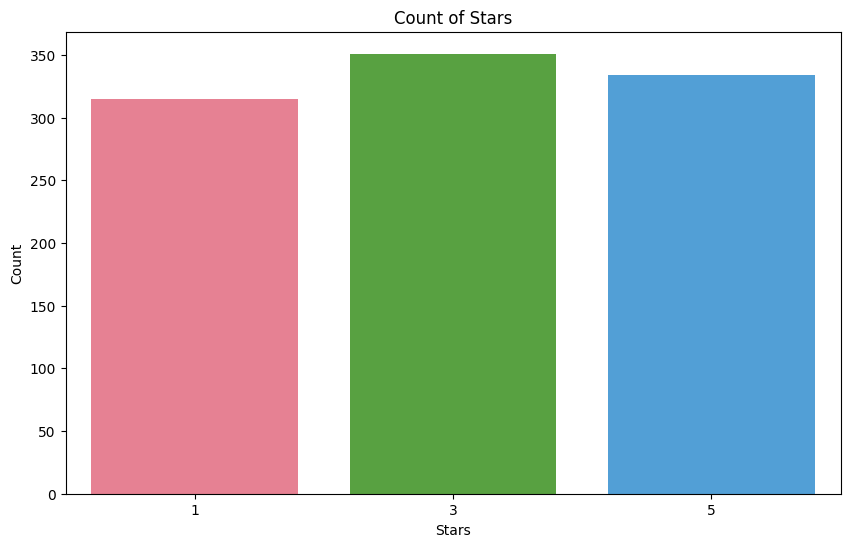

In [ ]:
# creating countplot for unique stars
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='stars',palette='husl')
plt.xlabel('Stars')
plt.ylabel('Count')
plt.title('Count of Stars')
plt.show()

In [ ]:
# creating sentiment function
def get_sentiment(stars):
  if stars<=2:
    return 'negative'
  elif stars==3:
    return 'neutral'
  else:
    return 'positive'

# creating new sentiment col in df
df['sentiment']=df['stars'].apply(get_sentiment)
df['sentiment']

,sentiment
0,neutral
1,negative
2,negative
3,positive
4,neutral
...,...
995,neutral
996,neutral
997,positive
998,neutral


/tmp/ipython-input-2907209892.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='sentiment',palette='viridis')


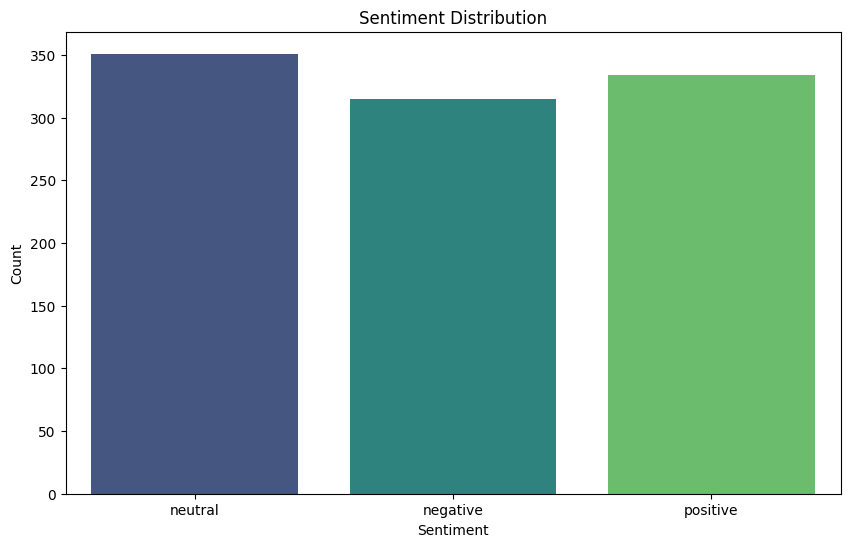

In [ ]:
# creating countplot of sentiment distribution
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='sentiment',palette='viridis')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Distribution')
plt.show()

In [ ]:
# spliting data into x & y
x=df['cleaned_review']
y=df['stars']

In [ ]:
# train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
# text vectorization

# creating vectorization object
vectorizer=TfidfVectorizer()

# transforming x_train & x_test data into vectors
x_train_vec=vectorizer.fit_transform(x_train)
x_test_vec=vectorizer.transform(x_test)

Model Training

In [ ]:
log=LogisticRegression()
log.fit(x_train_vec,y_train)

LogisticRegression()

In [ ]:
ytrain_pred=log.predict(x_train_vec)
ytrain_pred

array([1, 3, 3, 5, 5, 5, 3, 3, 3, 1, 5, 1, 1, 3, 1, 3, 1, 3, 1, 5, 5, 3,
       1, 1, 3, 3, 3, 3, 5, 5, 3, 3, 5, 3, 3, 1, 1, 1, 1, 3, 3, 1, 3, 3,
       3, 5, 1, 1, 1, 5, 3, 5, 3, 3, 3, 5, 3, 3, 5, 1, 1, 3, 3, 5, 1, 1,
       3, 1, 3, 3, 5, 3, 5, 3, 3, 1, 3, 1, 5, 3, 5, 5, 5, 5, 3, 3, 1, 5,
       5, 3, 5, 5, 3, 3, 5, 1, 1, 5, 1, 3, 5, 3, 3, 3, 1, 3, 3, 3, 5, 3,
       1, 5, 5, 1, 5, 3, 5, 3, 5, 1, 3, 1, 3, 5, 5, 3, 1, 3, 1, 3, 3, 5,
       5, 1, 1, 3, 1, 5, 5, 5, 1, 5, 1, 3, 5, 1, 5, 3, 3, 1, 3, 3, 3, 1,
       3, 1, 5, 3, 5, 5, 5, 5, 1, 5, 5, 1, 5, 5, 1, 5, 3, 3, 5, 3, 1, 1,
       1, 3, 5, 1, 1, 3, 3, 1, 5, 1, 3, 5, 3, 1, 3, 1, 5, 5, 3, 3, 1, 5,
       3, 1, 3, 5, 3, 5, 1, 5, 1, 1, 5, 3, 1, 3, 1, 1, 1, 1, 5, 5, 1, 5,
       3, 3, 3, 5, 5, 1, 1, 5, 5, 3, 3, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 5,
       3, 1, 3, 5, 1, 3, 1, 5, 5, 5, 5, 5, 1, 1, 1, 3, 1, 1, 1, 3, 3, 1,
       3, 5, 3, 3, 5, 3, 3, 1, 1, 5, 1, 3, 5, 3, 5, 1, 1, 3, 3, 1, 1, 3,
       3, 3, 1, 3, 3, 5, 1, 3, 3, 1, 1, 3, 3, 1, 3,

In [ ]:
# model evaluation on training data
print(accuracy_score(y_train,ytrain_pred))
print(classification_report(y_train,ytrain_pred))

1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       252
           3       1.00      1.00      1.00       281
           5       1.00      1.00      1.00       267

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



In [ ]:
ytest_pred=log.predict(x_test_vec)
ytest_pred

array([3, 1, 3, 1, 3, 1, 3, 5, 3, 5, 1, 3, 1, 3, 1, 5, 1, 5, 3, 1, 5, 3,
       5, 5, 1, 3, 3, 3, 5, 1, 1, 3, 1, 5, 1, 5, 3, 1, 1, 1, 3, 1, 1, 3,
       1, 3, 5, 3, 5, 1, 1, 3, 5, 3, 1, 3, 3, 5, 3, 3, 3, 5, 5, 5, 5, 5,
       3, 1, 3, 5, 1, 1, 5, 5, 5, 5, 3, 1, 5, 3, 3, 3, 5, 5, 5, 1, 5, 5,
       5, 3, 1, 5, 5, 3, 3, 5, 5, 5, 3, 1, 3, 3, 1, 5, 5, 3, 1, 5, 5, 5,
       5, 5, 3, 3, 5, 3, 1, 1, 1, 1, 1, 1, 1, 5, 5, 5, 3, 3, 1, 5, 1, 3,
       3, 3, 3, 3, 5, 3, 5, 1, 1, 1, 3, 5, 3, 1, 3, 1, 1, 3, 3, 1, 1, 3,
       5, 1, 1, 1, 5, 1, 3, 3, 1, 1, 5, 5, 3, 3, 3, 3, 5, 5, 5, 1, 5, 1,
       3, 3, 1, 5, 5, 1, 5, 3, 1, 3, 5, 3, 5, 3, 5, 1, 5, 3, 1, 3, 1, 3,
       1, 5])

In [ ]:
# model evaluation on testing data
print(accuracy_score(y_test,ytest_pred))
print(classification_report(y_test,ytest_pred))

1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        63
           3       1.00      1.00      1.00        70
           5       1.00      1.00      1.00        67

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [ ]:
from sklearn.cluster import KMeans

kmeans=KMeans(n_clusters=3,random_state=0).fit(x_train_vec)
kmeans

KMeans(n_clusters=3, random_state=0)

In [ ]:
yk_pred=kmeans.predict(x_train_vec)
yk_pred

array([2, 1, 1, 0, 1, 0, 0, 0, 1, 1, 2, 2, 2, 1, 0, 1, 1, 1, 0, 2, 1, 1,
       0, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 0, 0, 2, 1, 1, 2, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 2, 0, 2, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1,
       2, 1, 1, 0, 1, 1, 1, 2, 2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1,
       2, 1, 1, 1, 2, 1, 2, 0, 2, 0, 0, 1, 1, 2, 1, 1, 2, 1, 1, 0, 0, 2,
       1, 1, 2, 1, 1, 1, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       1, 0, 1, 1, 2, 2, 1, 2, 1, 2, 2, 0, 2, 2, 1, 2, 1, 0, 2, 0, 1, 0,
       1, 1, 1, 1, 2, 1, 1, 0, 2, 2, 0, 1, 0, 1, 1, 1, 2, 1, 1, 0, 0, 2,
       1, 1, 1, 2, 1, 2, 2, 0, 0, 2, 2, 1, 1, 1, 1, 1, 2, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 0, 1, 2, 2, 0, 1, 1, 1, 1, 1, 1,
       0, 2, 1, 1, 1, 0, 1, 1, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 1, 1, 1, 0,
       1, 2, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 2, 2, 0, 1, 0, 1, 1, 1,
       1, 1, 2, 1, 1, 2, 2, 1, 1, 2, 1, 1, 1, 2, 1,

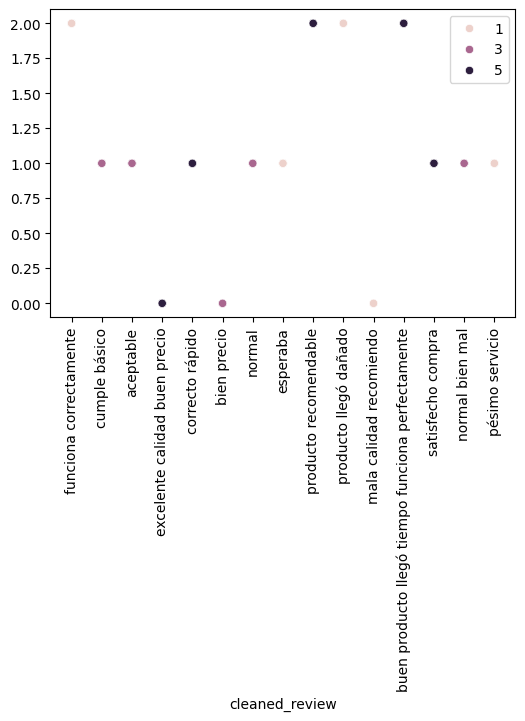

In [ ]:
# creating scatterplot between x_train & yk_pred
plt.figure(figsize=(6,4))
sns.scatterplot(x=x_train,y=yk_pred,hue=ytrain_pred)
plt.xticks(rotation=90)
plt.show()

In [ ]:
# save best model to pickle file
import pickle
pickle.dump(log,open("log_model.pkl","wb"))

In [ ]:
# Create a prediction function
def predict_sentiment(review_vec):
  final_model = pickle.load(open('log_model.pkl', 'rb'))
  prediction = final_model.predict(review_vec)
  if prediction <= 2:
    print("Negative Review")
  elif prediction == 3:
    print("Neutral Review")
  else:
    print("Positive Review")

In [ ]:
input_data = x_train_vec[5]
input_data

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4 stored elements and shape (1, 27)>

In [ ]:
log.predict(input_data)

array([5])

In [ ]:
predict_sentiment(input_data)

Positive Review


In [ ]:
data=x_train_vec[1]
data

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2 stored elements and shape (1, 27)>

In [ ]:
log.predict(data)

array([3])

In [ ]:
predict_sentiment(data)

Neutral Review
